In [1]:
!nvidia-smi

Tue Apr  7 17:07:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip install medmnist

In [44]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import torch.autograd as autograd
import math
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import torch.autograd as autograd
import math
import medmnist
from medmnist import INFO, Evaluator
from matplotlib import pyplot as plt
from itertools import combinations_with_replacement
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")
class ClassicNetwork(nn.Module):
    def __init__(self, layer_sizes,bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[z for l in layer_sizes
              for z in [nn.Linear(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# Set up signed Kaiming initialization.
def signed_kaiming_constant_(tensor, a=0, mode='fan_in', nonlinearity='relu', k=0.5, sparsity=0):
    fan = nn.init._calculate_correct_fan(tensor, mode)  # calculating correct fan, depends on shape and type of nn
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = (gain / math.sqrt(fan))
    # scale by (1/sqrt(k))
    if k != 0:
        std *= (1 / math.sqrt(k))
    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            mask = (torch.rand_like(tensor) > sparsity).float()  # Keeps (1 - sparsity)% weights
            tensor *= mask
        return tensor

# A function to retreive a subset of the top k% of the weights by their score.
# The gradient is estimated by the identity (i.e. it goes "straight-through").
# See the paper "What's Hidden in a Randomly Weighted Neural Network?" for
# more details (https://arxiv.org/abs/1911.13299)
# (this code adapted from https://github.com/iceychris/edge-popup)
class GetSubnet(autograd.Function):
    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Get the subnetwork by sorting the scores and using the top k%
        out = scores.clone()
        _, idx = scores.flatten().sort()
        j = int((1-k) * scores.numel())
        # flat_out and out access the same memory.
        flat_out = out.flatten()
        flat_out[idx[:j]] = 0
        flat_out[idx[j:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # send the gradient g straight-through on the backward pass.
        return grad, None

class LinearSubnet(nn.Linear):
    def __init__(self, in_features, out_features, init=signed_kaiming_constant_, mask_dict_keys=[], **kwargs):
        super().__init__(in_features, out_features, **kwargs)
        init(self.weight)
        self.scores = nn.Parameter(torch.randn(out_features,2*in_features))
        self.weight.requires_grad_(False)
        if self.bias is not None:
            self.bias_scores = nn.Parameter(torch.randn(2,out_features))
            self.bias.requires_grad_(False)
            self.bias_scores.requires_grad_(True)
        self.mask_dictionary = {key:{'scores':self.scores.data.clone(),'bias scores':self.scores.data.clone()} for key in mask_dict_keys}
        self.mode= "mask"
        self.k=0.5
    def forward(self, x):
      if self.mode!= "static":
        mask = GetSubnet.apply(self.scores.abs(),self.k)
        weight = self.weight * mask[:, :self.weight.shape[-1]]
        if self.bias is not None:
          bias_mask = GetSubnet.apply(self.bias_scores.abs(),self.k)
          bias = self.bias * bias_mask[0,:self.bias.shape[-1]]
          return F.linear(x, weight, bias)
        return F.linear(x,weight)
      else:
        return F.linear(x,self.weight)

    def toggle_mode(self, mode):
        self.mode = mode
        if mode=='classic':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(False)
        if mode=='mask':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(True)
        if mode=='hybrid':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(True)
        if mode=='static':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(False)

class Network(nn.Module):
    def __init__(self, layer_sizes, init=signed_kaiming_constant_, bias=True, mask_dict_keys=[]):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
                *[z for i,l in enumerate(layer_sizes)
                  for z in [LinearSubnet(l[0], l[1],bias=bias, mask_dict_keys=mask_dict_keys), nn.ReLU()]][:-1]
            )
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)
    def toggle_mode(self, mode):
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.toggle_mode(mode)
    def set_ks(self,ks):
        i=0
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.k=ks[i]
                i+=1
    def set_mask(self,data_set_name):
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.scores=nn.Parameter(layer.mask_dictionary[data_set_name]['scores'])
                layer.bias_scores=nn.Parameter(layer.mask_dictionary[data_set_name]['bias scores'])
                layer.scores.to(device)
                layer.bias_scores.to(device)
                self.toggle_mode('mask')

Using cuda device


In [10]:

def getTrainingDataLoaders(data_set_name, download=True, BATCH_SIZE=128):
    data_flag = data_set_name

    info = INFO[data_flag]
    task = info['task']
    n_channels = info['n_channels']
    n_classes = len(info['label'])

    DataClass = getattr(medmnist, info['python_class'])

    # RGBtransform = transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.size(0)==1 else x)

    # preprocessing
    if n_channels == 3:
        data_transform = v2.Compose([
            v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
            v2.Normalize(mean=[.5], std=[.5])
        ])

    if n_channels == 1:
        data_transform = v2.Compose([
            v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
            v2.RGB(),
            v2.Normalize(mean=[.5], std=[.5])
        ])

    # load the data
    train_dataset = DataClass(split='train', transform=data_transform, download=download)
    test_dataset = DataClass(split='test', transform=data_transform, download=download)

    pil_dataset = DataClass(split='train', download=download)

    # encapsulate data into dataloader form
    train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
    test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
    return info, task, n_classes, train_loader, train_loader_at_eval, test_loader

In [11]:
# Define a training function that returns a list of the losses during training.
def trainit(model,
            NUM_EPOCHS,
            train_loader,
            optimizer,
            task,
            n_classes,
            return_losses=False,
            no_progress=False):
  # define loss function
  if task == "multi-label, binary-class":
      criterion = nn.BCEWithLogitsLoss()
  else:
      criterion = nn.CrossEntropyLoss()
  if return_losses:
      losses = []
  # iterate over epochs for training run
  for epoch in range(NUM_EPOCHS):
      model.train()
      if no_progress:
        loader = train_loader
      else:
        loader=tqdm(train_loader)
      for inputs, targets in loader:
          inputs  = inputs.to(device, non_blocking=True)
          targets = targets.to(device, non_blocking=True)
          # forward + backward + optimize
          optimizer.zero_grad()
          outputs = model(inputs)[:,0:n_classes]
          if task == 'multi-label, binary-class':
              targets = targets.to(torch.float32)
              loss = criterion(outputs, targets)
          else:
              targets = targets.squeeze(1)
              loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
          if return_losses:
              losses.append(loss.item())
  if return_losses:
      return losses

# Define an evaluation function
def test(split,
         model,
         train_loader_at_eval,
         test_loader,
         task,
         n_classes,
         data_flag,
         return_metrics=False):
    # define loss function
    if task == "multi-label, binary-class":
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()
    model.eval()
    y_true = torch.tensor([])
    y_score = torch.tensor([])

    data_loader = train_loader_at_eval if split == 'train' else test_loader

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs  = inputs.to(device, non_blocking=True)
            inputs = inputs.to(torch.float32)
            targets = targets.to(device, non_blocking=True)
            targets = targets.to(torch.float32)
            outputs = model(inputs)[:,0:n_classes]

            if task == 'multi-label, binary-class':
                outputs = outputs.softmax(dim=-1)
            else:
                targets = targets.squeeze(1)
                outputs = outputs.softmax(dim=-1)
                targets = targets.float().resize_(len(targets), 1)
            y_true = y_true.to(device, non_blocking=True)
            y_score = y_score.to(device, non_blocking=True)
            y_true = torch.cat((y_true, targets), 0)
            y_score = torch.cat((y_score, outputs), 0)

        y_true = y_true.cpu().numpy()
        y_score = y_score.cpu().numpy()

        evaluator = Evaluator(data_flag, split)
        metrics = evaluator.evaluate(y_score)

        print('%s  auc: %.3f  acc:%.3f' % (split, *metrics))

        if return_metrics:
          return metrics

100%|██████████| 5/5 [00:00<00:00, 21.67it/s]


==> Evaluating ...
test  auc: 0.616  acc:0.737


100%|██████████| 55/55 [00:02<00:00, 25.14it/s]


==> Evaluating ...
test  auc: 0.794  acc:0.673


100%|██████████| 762/762 [00:39<00:00, 19.24it/s]


...

==> Evaluating ...
test  auc: 0.933  acc:0.683


100%|██████████| 109/109 [00:05<00:00, 19.50it/s]


==> Evaluating ...
test  auc: 0.887  acc:0.513


100%|██████████| 704/704 [00:27<00:00, 25.36it/s]


==> Evaluating ...
test  auc: 0.870  acc:0.574


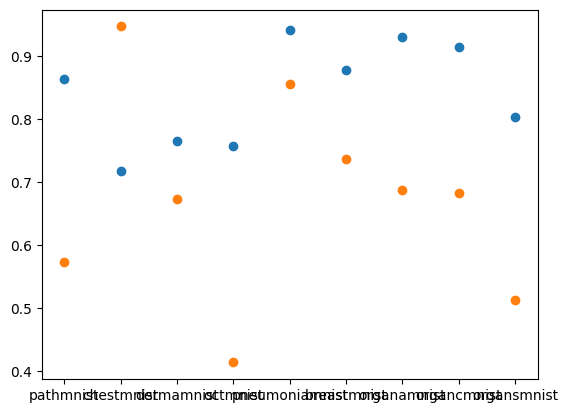

In [48]:
layer_sizes=[[3*28*28,512],[512, 14]]
NUM_EPOCHS = 10
best_from_benchmark = [('pathmnist',0.864),('chestmnist',0.718), ('dermamnist',0.766), ('octmnist',0.758),('pneumoniamnist',0.941), ('breastmnist',0.878), ('organamnist',0.931), ('organcmnist',0.915), ('organsmnist',0.803)]
best_from_subnet_search = []
data_sets_to_test=['breastmnist','dermamnist','octmnist','chestmnist','pneumoniamnist','organamnist','organcmnist','organsmnist','pathmnist']
model = Network(layer_sizes=layer_sizes, mask_dict_keys=data_sets_to_test)
model.to(device)
mask_dictionary = {data_set_name:{'mask':[]} for data_set_name in data_sets_to_test}

for data_set_name in data_sets_to_test:
  model.set_mask(data_set_name)
  model.to(device)
  info, task, n_classes, train_loader, train_loader_at_eval, test_loader = getTrainingDataLoaders(data_set_name)
  losses=trainit(model,NUM_EPOCHS,train_loader,optim.Adam(model.parameters()),task=task,n_classes=14, return_losses=True)
  print('==> Evaluating ...')
  best_from_subnet_search.append((data_set_name,test('test' , model, train_loader_at_eval, test_loader, task, n_classes, data_set_name,return_metrics=True)[1]))
  for layer in model.layers:
    if isinstance(layer, LinearSubnet):
        scores=layer.scores.data
        bias_scores=layer.bias_scores.data
        mask = GetSubnet.apply(scores.abs(),layer.k)[:,:layer.weight.shape[-1]]
        bias_mask = GetSubnet.apply(bias_scores.abs(),layer.k)[0,:layer.bias.shape[-1]]
        mask_dictionary[data_set_name]['mask'].append(mask)
        mask_dictionary[data_set_name]['mask'].append(bias_mask)

fig, ax = plt.subplots()
ax.scatter(x=[i[0] for i in best_from_benchmark],y=[i[1] for i in best_from_benchmark],label='Benchmark')
ax.scatter(x=[i[0] for i in best_from_subnet_search],y=[i[1] for i in best_from_subnet_search],label='Ours')

1079769
1143573


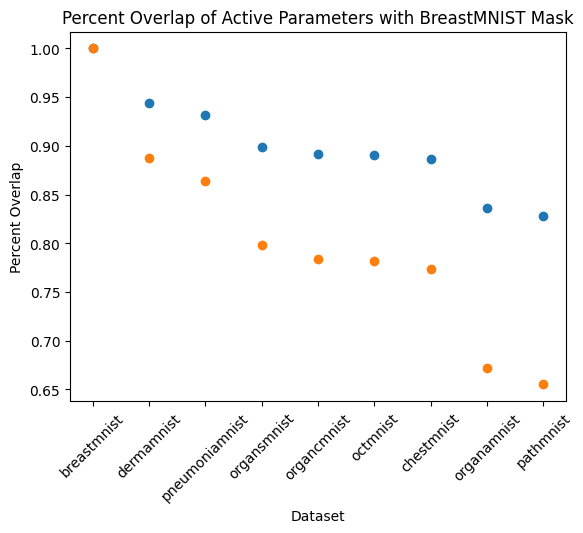

In [50]:
def percent_common_in_mask_list(a,b):
  return sum((m==b[n]).sum().item()for n,m in enumerate(a))/sum(math.prod(list(m.size())) for m in a)
def percent_common_in_mask_list_active_only(a,b):
  return percent_common_in_mask_list(a,b)-sum((torch.abs(m-b[n])).sum().item() for n,m in enumerate(a))/sum(math.prod(list(m.size())) for m in a)
print(sum((m==mask_dictionary['octmnist']['mask'][n]).sum().item()for n,m in enumerate(mask_dictionary['breastmnist']['mask'])))
print(sum((m==mask_dictionary['dermamnist']['mask'][n]).sum().item()for n,m in enumerate(mask_dictionary['breastmnist']['mask'])))

percents_common=[(data_set_name,percent_common_in_mask_list(mask_dictionary['breastmnist']['mask'],mask_dictionary[data_set_name]['mask'])) for data_set_name in mask_dictionary.keys()]
percents_common.sort(key=lambda x: x[1])
percents_common = percents_common[::-1]
percents_common_active=[(data_set_name,percent_common_in_mask_list_active_only(mask_dictionary['breastmnist']['mask'],mask_dictionary[data_set_name]['mask'])) for data_set_name in mask_dictionary.keys()]
percents_common_active.sort(key=lambda x: x[1])
percents_common_active = percents_common_active[::-1]
fig, ax = plt.subplots()
ax.scatter(x=[item[0] for item in percents_common],y=[item[1] for item in percents_common],label='Percent Overlap with BreastMNIST Mask')
ax.scatter(x=[item[0] for item in percents_common_active],y=[item[1] for item in percents_common_active])
plt.xticks(rotation=45)
# ax.set_ylim([0.0,1.01])
# ax.legend()
ax.set_xlabel('Dataset')
ax.set_ylabel('Percent Overlap')
ax.set_title('Percent Overlap of Active Parameters with BreastMNIST Mask')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(False)